### **Analysis of Boomlive.in Misinformation Data**

In [1]:
# Import required modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [16]:
# Load the data
# There are three different datasets, so we will load them separately
data1 = pd.read_csv('boomlive_data_cleaned.csv', encoding='unicode_escape')
data2 = pd.read_csv('boomlive_data_4.csv')
data3 = pd.read_csv('boomlive_data_5.csv')

In [17]:
# Few rows of the data
data1.head(3)

,Category,Link,Heading,Sub_heading,Author,Date,Claim,Fact_check,Claim_summary,Claimed_by,Fact_check_summary,Links,Year,Month
0,fact check,https://www.boomlive.in/fact-check/awami-leagu...,bangladeshi actor being heckled on video false...,"according to local reports, mishti subas was c...",Archis Chowdhury,10/10/2024 14:16,video shows an american woman being heckled in...,boom identified the woman as bangladeshi actor...,video shows an american woman being heckled in...,social media users,FALSE,"['https://archive.is/607Xw', 'https://www.face...",2024,10
1,fast check,https://www.boomlive.in/fast-check/morphed-pho...,morphed photo falsely shared as patanjali sell...,boom found that the viral image was morphed fr...,Yangchula Bhutia,10/9/2024 13:33,an image showing a beef biryani spice mix with...,boom found that the viral image claiming patan...,a viral image claims that patanjali manufactur...,facebook,FALSE,NaN,2024,10
2,fact check,https://www.boomlive.in/fact-check/video-of-ma...,video of man killed by cousins in bangladesh f...,boom found that the deceased man's name is han...,Tausif Akbar,10/8/2024 18:36,video shows a hindu man killed by slitting his...,the incident happened because of personal enmi...,video shows body of a hindu man killed by slit...,"facebook users, x users",FALSE,[],2024,10


In [18]:
# shape of the data files
print(data1.shape)
print(data2.shape)
print(data3.shape)

(3133, 14)
(250, 12)
(212, 12)


In [19]:
# Combine the data files
data = pd.concat([data2, data3], axis=0)

In [20]:
# Few rows of the combined data
data.head()

,Category,Link,Heading,Sub_heading,Author,Date,Claim,Fact_check,Claim_summary,Claimed_by,Fact_check_summary,Links
0,Fact Check,https://www.boomlive.in/social-media-posts-cla...,Social Media Posts Claim Unnao Rape Survivor H...,Viral posts are bidding emotional farewells to...,Sumit Usha |,1 Aug 2019 2:01 PM IST,A compilation of two photos - an injured woman...,NaN,Unnao rape survivor is dead,Facebook pages and Twitter handles,FALSE,['https://www.facebook.com/hashtag/होनी_को_कौन...
1,Fact Check,https://www.boomlive.in/video-showing-flooded-...,Video Showing Flooded Mexico Airport Back As M...,Since 2017 the same video from Mexico has been...,Anmol Alphonso |,1 Aug 2019 12:36 PM IST,This is the tarmac at Mumbai’s Chhatrapati Shi...,NaN,Video shows tarmac at Mumbai’s Chhatrapati Shi...,Social media posts,FALSE,NaN
2,Fact Check,https://www.boomlive.in/bengaluru-police-rubbi...,Bengaluru Police Rubbishes Child Kidnapping Ru...,A viral message on social media claimed that a...,Anmol Alphonso |,31 July 2019 1:36 PM IST,NaN,NaN,Kidnapped Just 25 Minutes Back From Nagarbhavi...,Facebook Posts,FALSE,['https://twitter.com/CPBlr/status/11551474910...
3,Fact Check,https://www.boomlive.in/shiva-idol-damaged-by-...,"Shiva Idol Damaged By Lightning, Preliminary I...",BOOM spoke to Arjuni Morgaon police who denied...,Anmol Alphonso |,30 July 2019 5:00 PM IST,A preliminary investigation into the destructi...,NaN,Photos shows a Shiva statue broken by Muslims ...,RealHistoriPix,FALSE,['https://www.business-standard.com/article/pt...
4,Fact Check,https://www.boomlive.in/sim-swap-fraud-all-you...,SIM Swap Fraud: All You Need To Know And The S...,"To dispel myths around the SIM swap fraud, BOO...",Archis Chowdhury |,29 July 2019 8:19 PM IST,SIM swap fraud is a real scam that has already...,NaN,NaN,NaN,NaN,['https://timesofindia.indiatimes.com/business...


In [21]:
# shape of the combined data
data.shape

(462, 12)

In [22]:
# columns of the data
data.columns

Index(['Category', 'Link', 'Heading', 'Sub_heading', 'Author', 'Date', 'Claim',
       'Fact_check', 'Claim_summary', 'Claimed_by', 'Fact_check_summary',
       'Links'],
      dtype='object')

In [23]:
# remove the duplicate rows
data = data.drop_duplicates()

# shape of the data after removing duplicates
data.shape

(462, 12)

In [24]:
# vale counts of Category column
data['Category'].value_counts()

Category
Fact Check    461
Business        1
Name: count, dtype: int64

In [25]:
# category to lower
data['Category'] = data['Category'].str.lower()

In [26]:
# vale counts of Category column
data['Category'].value_counts()

Category
fact check    461
business        1
Name: count, dtype: int64

In [27]:
# drop other than fact check
data = data[data['Category'] == 'fact check']

In [28]:
# extract the date from the 'Date' column
data['Date'] = pd.to_datetime(data['Date'])
data['Year'] = data['Date'].dt.year
data['Month'] = data['Date'].dt.month

C:\Users\prita\AppData\Local\Temp\ipykernel_18320\419961293.py:2: FutureWarning: Parsed string "1 Aug 2019 2:01 PM IST" included an un-recognized timezone "IST". Dropping unrecognized timezones is deprecated; in a future version this will raise. Instead pass the string without the timezone, then use .tz_localize to convert to a recognized timezone.
  data['Date'] = pd.to_datetime(data['Date'])
C:\Users\prita\AppData\Local\Temp\ipykernel_18320\419961293.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data['Date'] = pd.to_datetime(data['Date'])
C:\Users\prita\AppData\Local\Temp\ipykernel_18320\419961293.py:2: FutureWarning: Parsed string "1 Aug 2019 12:36 PM IST" included an un-recognized timezone "IST". Dropping unrecognized timezones is deprecated; in a future version this will raise. Instead pass the string without the timezone, then use .tz_l

In [29]:
#shape of the data
data.shape

(461, 14)

In [30]:
data.head()

,Category,Link,Heading,Sub_heading,Author,Date,Claim,Fact_check,Claim_summary,Claimed_by,Fact_check_summary,Links,Year,Month
0,fact check,https://www.boomlive.in/social-media-posts-cla...,Social Media Posts Claim Unnao Rape Survivor H...,Viral posts are bidding emotional farewells to...,Sumit Usha |,2019-08-01 14:01:00,A compilation of two photos - an injured woman...,NaN,Unnao rape survivor is dead,Facebook pages and Twitter handles,FALSE,['https://www.facebook.com/hashtag/होनी_को_कौन...,2019,8
1,fact check,https://www.boomlive.in/video-showing-flooded-...,Video Showing Flooded Mexico Airport Back As M...,Since 2017 the same video from Mexico has been...,Anmol Alphonso |,2019-08-01 12:36:00,This is the tarmac at Mumbai’s Chhatrapati Shi...,NaN,Video shows tarmac at Mumbai’s Chhatrapati Shi...,Social media posts,FALSE,NaN,2019,8
2,fact check,https://www.boomlive.in/bengaluru-police-rubbi...,Bengaluru Police Rubbishes Child Kidnapping Ru...,A viral message on social media claimed that a...,Anmol Alphonso |,2019-07-31 13:36:00,NaN,NaN,Kidnapped Just 25 Minutes Back From Nagarbhavi...,Facebook Posts,FALSE,['https://twitter.com/CPBlr/status/11551474910...,2019,7
3,fact check,https://www.boomlive.in/shiva-idol-damaged-by-...,"Shiva Idol Damaged By Lightning, Preliminary I...",BOOM spoke to Arjuni Morgaon police who denied...,Anmol Alphonso |,2019-07-30 17:00:00,A preliminary investigation into the destructi...,NaN,Photos shows a Shiva statue broken by Muslims ...,RealHistoriPix,FALSE,['https://www.business-standard.com/article/pt...,2019,7
4,fact check,https://www.boomlive.in/sim-swap-fraud-all-you...,SIM Swap Fraud: All You Need To Know And The S...,"To dispel myths around the SIM swap fraud, BOO...",Archis Chowdhury |,2019-07-29 20:19:00,SIM swap fraud is a real scam that has already...,NaN,NaN,NaN,NaN,['https://timesofindia.indiatimes.com/business...,2019,7


C:\Users\prita\AppData\Local\Temp\ipykernel_18320\3659377555.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Category', data=data, palette='coolwarm')


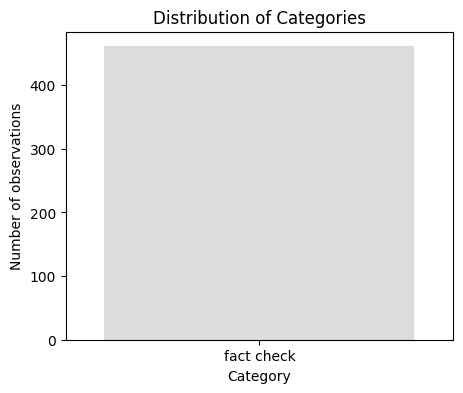

In [31]:
# histogram of the Category column using seaborn
plt.figure(figsize=(5, 4))
sns.countplot(x='Category', data=data, palette='coolwarm')
plt.title('Distribution of Categories')
plt.xlabel('Category')
plt.ylabel('Number of observations')
plt.show()

In [32]:
# convert the Fact_check_summary column to lower case
data['Fact_check_summary'] = data['Fact_check_summary'].str.lower()

In [33]:
data['Fact_check_summary'].value_counts()

Fact_check_summary
false            337
misleading        34
fake              16
true              10
satire             2
partly true        2
unknown            1
fasle              1
false, satire      1
Name: count, dtype: int64

In [19]:
# drop rows with Fcat_check_summary as NaN
data = data.dropna(subset=['Fact_check_summary'])

In [34]:
# change fake and fasle to false in the Fact_check_summary column
data['Fact_check_summary'] = data['Fact_check_summary'].replace('fake', 'false')

In [35]:
# keep `false` 'misleading', and `true` in the Fact_check_summary column
data = data[data['Fact_check_summary'].isin(['false', 'misleading', 'true'])]

# shape of the data
data.shape

(397, 14)

C:\Users\prita\AppData\Local\Temp\ipykernel_18320\600282177.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Fact_check_summary', data=data, palette='coolwarm')


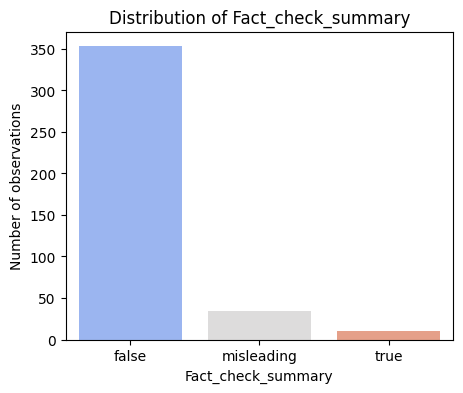

In [36]:

# histogram of the Fact_check_summary column using seaborn
plt.figure(figsize=(5, 4))
sns.countplot(x='Fact_check_summary', data=data, palette='coolwarm')
plt.title('Distribution of Fact_check_summary')
plt.xlabel('Fact_check_summary')
plt.ylabel('Number of observations')
plt.show()

In [23]:
data.columns

Index(['Category', 'Link', 'Heading', 'Sub_heading', 'Author', 'Date', 'Claim',
       'Fact_check', 'Claim_summary', 'Claimed_by', 'Fact_check_summary',
       'Links'],
      dtype='object')

In [37]:
# convert other string columns to lower case
columns_to_lower = ['Category', 'Heading', 'Sub_heading', 'Claim',
       'Fact_check', 'Claim_summary', 'Claimed_by']

for col in columns_to_lower:
    data[col] = data[col].str.lower()


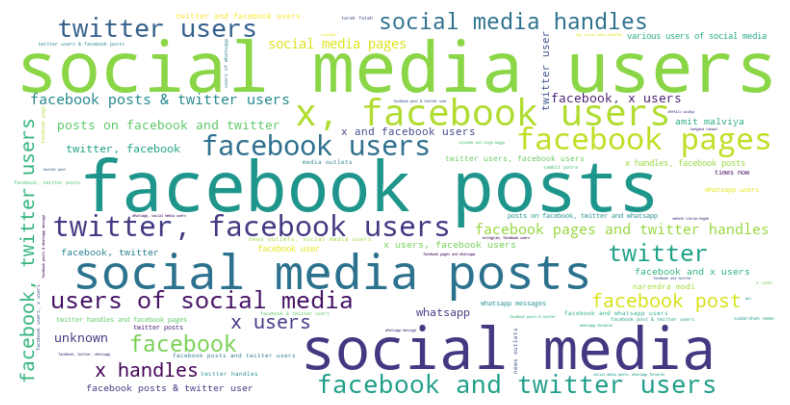

In [40]:
# make a word cloud of the Claimed_by column
from wordcloud import WordCloud

# Step 1: Count frequencies of each category
category_counts = data['Claimed_by'].value_counts().to_dict()

# Step 2: Generate the word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(category_counts)

# Step 3: Plot the word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

In [38]:
# concate data and data1
data3 = pd.concat([data, data1], axis=0)

# shape of the data
data3.shape

(3530, 14)

In [39]:
data3.head()

,Category,Link,Heading,Sub_heading,Author,Date,Claim,Fact_check,Claim_summary,Claimed_by,Fact_check_summary,Links,Year,Month
0,fact check,https://www.boomlive.in/social-media-posts-cla...,social media posts claim unnao rape survivor h...,viral posts are bidding emotional farewells to...,Sumit Usha |,2019-08-01 14:01:00,a compilation of two photos - an injured woman...,NaN,unnao rape survivor is dead,facebook pages and twitter handles,false,['https://www.facebook.com/hashtag/होनी_को_कौन...,2019,8
1,fact check,https://www.boomlive.in/video-showing-flooded-...,video showing flooded mexico airport back as m...,since 2017 the same video from mexico has been...,Anmol Alphonso |,2019-08-01 12:36:00,this is the tarmac at mumbai’s chhatrapati shi...,NaN,video shows tarmac at mumbai’s chhatrapati shi...,social media posts,false,NaN,2019,8
2,fact check,https://www.boomlive.in/bengaluru-police-rubbi...,bengaluru police rubbishes child kidnapping ru...,a viral message on social media claimed that a...,Anmol Alphonso |,2019-07-31 13:36:00,NaN,NaN,kidnapped just 25 minutes back from nagarbhavi...,facebook posts,false,['https://twitter.com/CPBlr/status/11551474910...,2019,7
3,fact check,https://www.boomlive.in/shiva-idol-damaged-by-...,"shiva idol damaged by lightning, preliminary i...",boom spoke to arjuni morgaon police who denied...,Anmol Alphonso |,2019-07-30 17:00:00,a preliminary investigation into the destructi...,NaN,photos shows a shiva statue broken by muslims ...,realhistoripix,false,['https://www.business-standard.com/article/pt...,2019,7
5,fact check,https://www.boomlive.in/crocodile-rescued-from...,crocodile rescued from ratnagiri drain shared ...,"boom spoke to divisional forest officer, chipl...",Nivedita Niranjankumar |,2019-07-29 17:31:00,a two part video of forest officials trying to...,NaN,"crocodile found in dadar, mumbai",facebook posts,false,"['http://archive.is/TKDFt', 'http://archive.is...",2019,7


In [41]:
# data types of the columns
data3.dtypes

Category              object
Link                  object
Heading               object
Sub_heading           object
Author                object
Date                  object
Claim                 object
Fact_check            object
Claim_summary         object
Claimed_by            object
Fact_check_summary    object
Links                 object
Year                   int64
Month                  int64
dtype: object

In [42]:
# convert date to datetime
data3['Date'] = pd.to_datetime(data3['Date'])

In [43]:
# sort the data by date
data3 = data3.sort_values('Date')

data3.head()

,Category,Link,Heading,Sub_heading,Author,Date,Claim,Fact_check,Claim_summary,Claimed_by,Fact_check_summary,Links,Year,Month
210,fact check,https://www.boomlive.in/viral-fake-alert-has-p...,viral fake alert: has pm modi hired a makeup a...,a screenshot of pm modi's facial measurements ...,Srikanth R |,2018-10-24 15:32:00,NaN,NaN,pm modi hired a makeup artist at 15 lakh rupee...,facebook user,false,"['https://archive.is/cuZRK', 'https://www.mada...",2018,10
209,fact check,https://www.boomlive.in/did-pm-modi-reveal-his...,did pm modi reveal his pan number on twitter?:...,"no, the prime minister did not accidentally re...",Srikanth R |,2018-10-25 19:03:00,representational image,NaN,prime minister narendra modi accidentally reve...,social media,false,['https://twitter.com/BJP4India?ref_src=twsrc^...,2018,10
208,fact check,https://www.boomlive.in/photo-of-kerala-cop-ci...,photo of kerala cop circulated as cpm member a...,posts claimed man is a cpm worker in a policem...,Nivedita Niranjankumar |,2018-10-27 18:07:00,a photo of an uniformed police officer from ke...,NaN,cpm worker impersonated a policeman and assaul...,social media,false,['https://twitter.com/hashtag/Sabarimala?src=h...,2018,10
207,fact check,https://www.boomlive.in/no-sinead-oconnor-has-...,"no, sinéad o’connor has not converted to hindu...","no, sinead o'connor did not convert to hinduis...",BOOM FACT Check Team |,2018-10-29 16:54:00,NaN,NaN,sinéad o’connor converts to hinduism after fin...,social media,false,"['https://irelandoncraic.com', 'https://archiv...",2018,10
206,fact check,https://www.boomlive.in/photoshopped-image-sha...,photoshopped image shared to highlight dispari...,"no, this photo does not show a poor family aga...",BOOM FACT Check Team |,2018-10-29 18:36:00,NaN,NaN,image of a woman and her two children having a...,twitter user,false,"['https://t.co/H2wVdzWlxV', 'https://twitter.c...",2018,10


In [45]:
data3.tail(20)

,Category,Link,Heading,Sub_heading,Author,Date,Claim,Fact_check,Claim_summary,Claimed_by,Fact_check_summary,Links,Year,Month
5,fact check,https://www.boomlive.in/fact-check/fact-check-...,bangladeshi activist's speech cropped and shar...,the viral video has been cropped and decontext...,Srijanee Chakraborty,2024-10-06 14:57:00,a viral video claims that a muslim activist in...,the video of the speech delivered by banglades...,video shows a man giving hindus in bangladesh ...,social media users,misleading,['https://www.thedailystar.net/news/bangladesh...,2024,10
4,fact check,https://www.boomlive.in/fact-check/israel-pale...,viral claims of icj declaring israel an illega...,the icj ruling specifically pertains to israel...,Archis Chowdhury,2024-10-08 15:45:00,a video showing palestineâs foreign minister...,"the video is from july 2024, and shows the pal...",video shows palestinian foreign minister brief...,social media users,FALSE,['https://www.facebook.com/farjahan.shawon/vid...,2024,10
3,fact check,https://www.boomlive.in/fact-check/lebanon-tv-...,video from iraqi prank show peddled as lebanes...,boom found that the video is from an iraqi cha...,Nivedita Niranjankumar,2024-10-08 17:40:00,tv actress in lebanon slaps a maulvi for makin...,boom found that the video is from an iraqi cha...,lebanese tv actress slaps maulvi for insulting...,x and facebook users,FALSE,['https://youtu.be/fo-Dc6Hud5Q?si=knDtIUq-Vn4c...,2024,10
2,fact check,https://www.boomlive.in/fact-check/video-of-ma...,video of man killed by cousins in bangladesh f...,boom found that the deceased man's name is han...,Tausif Akbar,2024-10-08 18:36:00,video shows a hindu man killed by slitting his...,the incident happened because of personal enmi...,video shows body of a hindu man killed by slit...,"facebook users, x users",FALSE,[],2024,10
1,fast check,https://www.boomlive.in/fast-check/morphed-pho...,morphed photo falsely shared as patanjali sell...,boom found that the viral image was morphed fr...,Yangchula Bhutia,2024-10-09 13:33:00,an image showing a beef biryani spice mix with...,boom found that the viral image claiming patan...,a viral image claims that patanjali manufactur...,facebook,FALSE,NaN,2024,10
0,fact check,https://www.boomlive.in/fact-check/awami-leagu...,bangladeshi actor being heckled on video false...,"according to local reports, mishti subas was c...",Archis Chowdhury,2024-10-10 14:16:00,video shows an american woman being heckled in...,boom identified the woman as bangladeshi actor...,video shows an american woman being heckled in...,social media users,FALSE,"['https://archive.is/607Xw', 'https://www.face...",2024,10
2439,fact check,https://www.boomlive.in/fact-check/fake-news-a...,news outlets run ai-generated photo showing ra...,boom found that the viral black-and-white phot...,Anmol Alphonso,2024-10-11 18:43:00,a black-and-white photo circulating online dep...,boom found that the viral black-and-white phot...,old black-and-white photo shows a young ratan ...,"news 18 hindi, indiatimes",FALSE,"['https://perma.cc/9PFN-QQB7?type=standard', '...",2024,10
2438,fact check,https://www.boomlive.in/fact-check/fact-check-...,video of bangladeshi tiktoker attacked for all...,the incident is from chittagong's cox's bazar ...,Tausif Akbar,2024-10-14 11:41:00,video shows a hindu woman being beaten in bang...,the woman in the viral video is a bangladeshi ...,video shows a hindu woman being beaten in bang...,x and facebook users,FALSE,['https://x.com/Warlock_Shabby/status/18429898...,2024,10
2437,fact check,https://www.boomlive.in/fact-check/sunita-will...,sunita williams returning from space? old vide...,"since june 2024, williams has been aboard the ...",Archis Chowdhury,2024-10-14 14:20:00,a viral video claims that astronaut sunita wil...,the video going viral is from november 2012. s...,video shows nasa astronaut sunita williams ret...,social media users,FALSE,"['https://archive.is/77tsX', 'https://www.face...",2024,10
2436,fact check,https://www.boomliv

In [46]:
# read the data
data4 = pd.read_csv('boomlive_data_8.csv')

In [47]:
data4.head()

,Category,Link,Heading,Sub_heading,Author,Date,Claim,Fact_check,Claim_summary,Claimed_by,Fact_check_summary,Links,Year,Month
0,Fact Check,https://www.boomlive.in/fact-check/video-son-m...,Viral Posts Falsely Claim Son Married His Moth...,BOOM found that the visuals in the posts are f...,Anmol Alphonso,12/31/2024 15:49,Video shows Pakistani boy marrying his mother,A Pakistani youngster Abdul Ahad posted a hear...,Video shows Pakistani boy marrying his mother,Social media posts,FALSE,['https://x.com/Knight491656903/status/1873663...,2024,12
1,Fact Check,https://www.boomlive.in/fact-check/couple-publ...,Video Of Couple Beaten By Henchman In WB Peddl...,"The incident happened in Chopra, West Bengal i...",Anmol Alphonso,12/31/2024 11:50,Video shows a couple being publicly flogged in...,"The video is from Chopra, West Bengal, and not...",Video shows a couple being publicly flogged in...,Social media posts,FALSE,['https://indianexpress.com/article/world/bang...,2024,12
2,Fact Check,https://www.boomlive.in/fact-check/viral-image...,Viral Photo Does Not Show Manmohan Singh Touch...,The image is from 2011 and shows a representat...,Srijanee Chakraborty,12/30/2024 15:43,Viral image shows former Indian Prime Minister...,The man touching Sonia Gandhi's feet is a repr...,Viral image shows former Indian Prime Minister...,Social Media Users,FALSE,"['https://t.co/43ZyfojnWt', 'https://twitter.c...",2024,12
3,Fact Check,https://www.boomlive.in/fact-check/viral-video...,Video Does Not Show Hindu Woman Raped And Tort...,BOOM found that the woman in the video is a Mu...,Tausif Akbar,12/29/2024 14:04,Video shows a Hindu woman who was raped and to...,A local journalist confirmed to BOOM Banglades...,Video shows a Hindu woman who was raped and to...,Social Media Users,FALSE,['https://x.com/Asifurrahman71/status/18725269...,2024,12
4,Fact Check,https://www.boomlive.in/fact-check/bjp-delhi-d...,BJP Delhi Shares Edited Image To Show Potholes...,"The original photo, showed a damaged road, but...",Archis Chowdhury,12/29/2024 13:37,BJP Delhi shared an image claiming to depict p...,"BOOM found the image is dated, and has been di...",Image shows potholes on Delhi roads after rece...,"BJP Delhi, Amit Malviya",FALSE,"['https://archive.is/r4sm0', 'https://x.com/am...",2024,12


In [48]:
# convert to lower case
# convert other string columns to lower case
columns_to_lower = ['Category', 'Heading', 'Sub_heading', 'Claim',
       'Fact_check', 'Claim_summary', 'Claimed_by']

for col in columns_to_lower:
    data4[col] = data4[col].str.lower()

In [49]:
# data types of the columns
data4.dtypes

Category              object
Link                  object
Heading               object
Sub_heading           object
Author                object
Date                  object
Claim                 object
Fact_check            object
Claim_summary         object
Claimed_by            object
Fact_check_summary    object
Links                 object
Year                   int64
Month                  int64
dtype: object

In [50]:
# convert date to datetime
data4['Date'] = pd.to_datetime(data4['Date'])

In [51]:
# concate data3 and data4
data5 = pd.concat([data3, data4], axis=0)

# shape of the data
data5.shape

(3622, 14)

In [54]:
# sort the data by date
data5 = data5.sort_values('Date')

In [55]:
data5.head()

,Category,Link,Heading,Sub_heading,Author,Date,Claim,Fact_check,Claim_summary,Claimed_by,Fact_check_summary,Links,Year,Month
210,fact check,https://www.boomlive.in/viral-fake-alert-has-p...,viral fake alert: has pm modi hired a makeup a...,a screenshot of pm modi's facial measurements ...,Srikanth R |,2018-10-24 15:32:00,NaN,NaN,pm modi hired a makeup artist at 15 lakh rupee...,facebook user,false,"['https://archive.is/cuZRK', 'https://www.mada...",2018,10
209,fact check,https://www.boomlive.in/did-pm-modi-reveal-his...,did pm modi reveal his pan number on twitter?:...,"no, the prime minister did not accidentally re...",Srikanth R |,2018-10-25 19:03:00,representational image,NaN,prime minister narendra modi accidentally reve...,social media,false,['https://twitter.com/BJP4India?ref_src=twsrc^...,2018,10
208,fact check,https://www.boomlive.in/photo-of-kerala-cop-ci...,photo of kerala cop circulated as cpm member a...,posts claimed man is a cpm worker in a policem...,Nivedita Niranjankumar |,2018-10-27 18:07:00,a photo of an uniformed police officer from ke...,NaN,cpm worker impersonated a policeman and assaul...,social media,false,['https://twitter.com/hashtag/Sabarimala?src=h...,2018,10
207,fact check,https://www.boomlive.in/no-sinead-oconnor-has-...,"no, sinéad o’connor has not converted to hindu...","no, sinead o'connor did not convert to hinduis...",BOOM FACT Check Team |,2018-10-29 16:54:00,NaN,NaN,sinéad o’connor converts to hinduism after fin...,social media,false,"['https://irelandoncraic.com', 'https://archiv...",2018,10
206,fact check,https://www.boomlive.in/photoshopped-image-sha...,photoshopped image shared to highlight dispari...,"no, this photo does not show a poor family aga...",BOOM FACT Check Team |,2018-10-29 18:36:00,NaN,NaN,image of a woman and her two children having a...,twitter user,false,"['https://t.co/H2wVdzWlxV', 'https://twitter.c...",2018,10


In [56]:
data5.tail()

,Category,Link,Heading,Sub_heading,Author,Date,Claim,Fact_check,Claim_summary,Claimed_by,Fact_check_summary,Links,Year,Month
4,fact check,https://www.boomlive.in/fact-check/bjp-delhi-d...,bjp delhi shares edited image to show potholes...,"the original photo, showed a damaged road, but...",Archis Chowdhury,2024-12-29 13:37:00,bjp delhi shared an image claiming to depict p...,"boom found the image is dated, and has been di...",image shows potholes on delhi roads after rece...,"bjp delhi, amit malviya",FALSE,"['https://archive.is/r4sm0', 'https://x.com/am...",2024,12
3,fact check,https://www.boomlive.in/fact-check/viral-video...,video does not show hindu woman raped and tort...,boom found that the woman in the video is a mu...,Tausif Akbar,2024-12-29 14:04:00,video shows a hindu woman who was raped and to...,a local journalist confirmed to boom banglades...,video shows a hindu woman who was raped and to...,social media users,FALSE,['https://x.com/Asifurrahman71/status/18725269...,2024,12
2,fact check,https://www.boomlive.in/fact-check/viral-image...,viral photo does not show manmohan singh touch...,the image is from 2011 and shows a representat...,Srijanee Chakraborty,2024-12-30 15:43:00,viral image shows former indian prime minister...,the man touching sonia gandhi's feet is a repr...,viral image shows former indian prime minister...,social media users,FALSE,"['https://t.co/43ZyfojnWt', 'https://twitter.c...",2024,12
1,fact check,https://www.boomlive.in/fact-check/couple-publ...,video of couple beaten by henchman in wb peddl...,"the incident happened in chopra, west bengal i...",Anmol Alphonso,2024-12-31 11:50:00,video shows a couple being publicly flogged in...,"the video is from chopra, west bengal, and not...",video shows a couple being publicly flogged in...,social media posts,FALSE,['https://indianexpress.com/article/world/bang...,2024,12
0,fact check,https://www.boomlive.in/fact-check/video-son-m...,viral posts falsely claim son married his moth...,boom found that the visuals in the posts are f...,Anmol Alphonso,2024-12-31 15:49:00,video shows pakistani boy marrying his mother,a pakistani youngster abdul ahad posted a hear...,video shows pakistani boy marrying his mother,social media posts,FALSE,['https://x.com/Knight491656903/status/1873663...,2024,12


In [57]:
# drop the duplicate rows
data5 = data5.drop_duplicates()

In [58]:
data5.shape

(3616, 14)

In [59]:
# drop te rows with month == 10 nad year == 2018
data5 = data5[~((data5['Month'] == 10) & (data5['Year'] == 2018))]

data5.shape

(3607, 14)

In [60]:
# save data to a csv file
data5.to_csv('boomlive_data_11_2018_to_12_2024.csv', index=False)

In [42]:
# conevrt Claimed by If it contains social media to social media users, if it contains whatsapp to whatsapp, if it contains facebook and twitter to  facebook and twitter users,
# if it only contains facebook to facebook users, if it only contains twitter to twitter users.
# Define function to categorize based on conditions
def categorize_claimed_by(value):
    if 'social media' in value:
        return 'social media users'
    elif 'whatsapp' in value:
        return 'whatsapp'
    elif 'facebook' in value and 'twitter' in value:
        return 'facebook and twitter users'
    elif 'facebook' in value:
        return 'facebook users'
    elif 'twitter' in value or 'x' in value:
        return 'twitter users'
    return value

# Apply the function to the column
data['Claimed_by'] = data['Claimed_by'].apply(categorize_claimed_by)


C:\Users\prita\AppData\Local\Temp\ipykernel_9816\1128880706.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Author', data=data, palette='coolwarm')


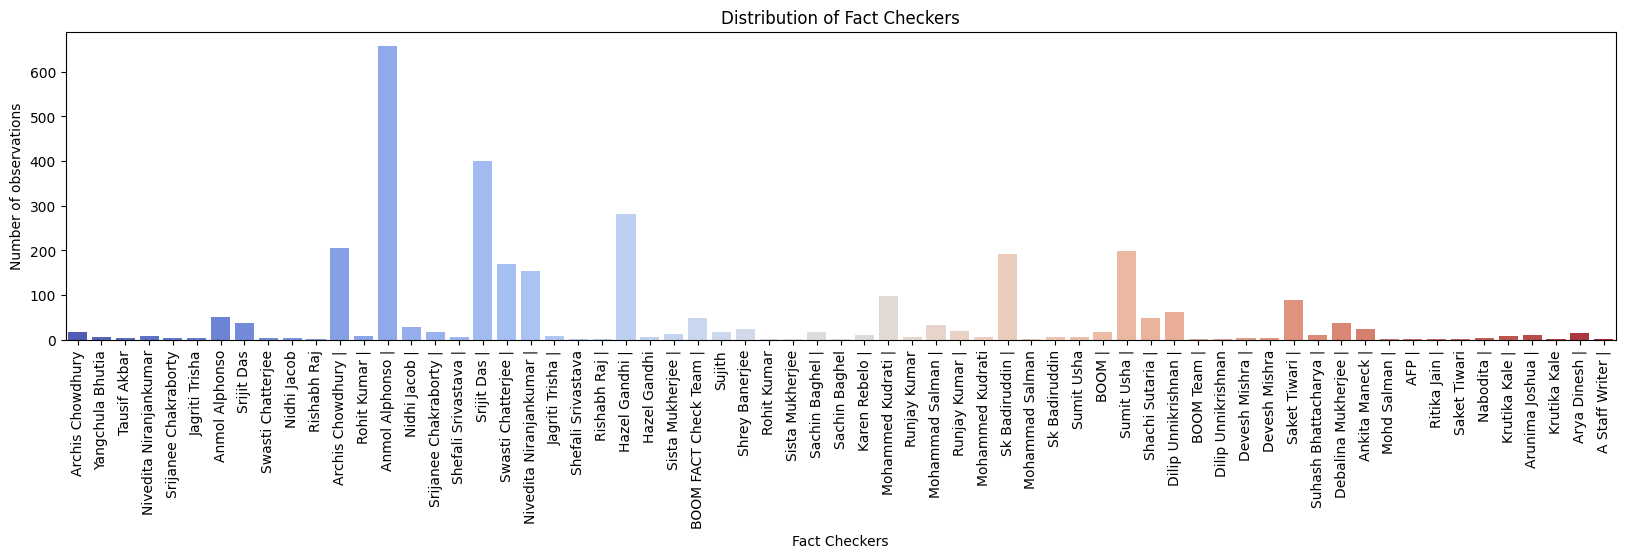

In [48]:
# histogram of authors column using seaborn
plt.figure(figsize=(20, 4))
sns.countplot(x='Author', data=data, palette='coolwarm')
plt.title('Distribution of Fact Checkers')
plt.xlabel('Fact Checkers')
plt.xticks(rotation=90)
plt.ylabel('Number of observations')
plt.show()

C:\Users\prita\AppData\Local\Temp\ipykernel_18320\861382603.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Year', data=data5, palette='coolwarm')


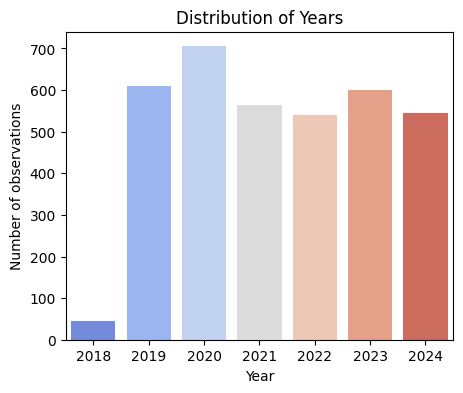

In [61]:
# histogram of the Year column using seaborn
plt.figure(figsize=(5, 4))
sns.countplot(x='Year', data=data5, palette='coolwarm')
plt.title('Distribution of Years')
plt.xlabel('Year')
plt.ylabel('Number of observations')
plt.show()

C:\Users\prita\AppData\Local\Temp\ipykernel_18320\2851261617.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Month', data=data5[data5['Year']==2024], palette='coolwarm')


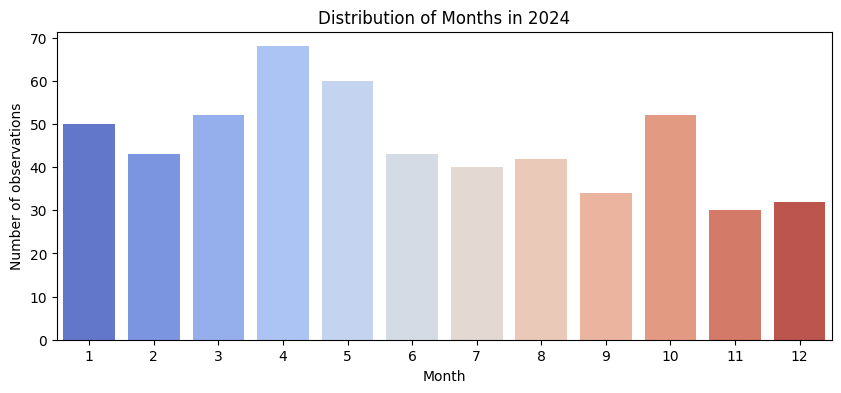

In [62]:
# histogram of the Month column using seaborn of year 2024
plt.figure(figsize=(10, 4))
sns.countplot(x='Month', data=data5[data5['Year']==2024], palette='coolwarm')
plt.title('Distribution of Months in 2024')
plt.xlabel('Month')
plt.ylabel('Number of observations')
plt.show()


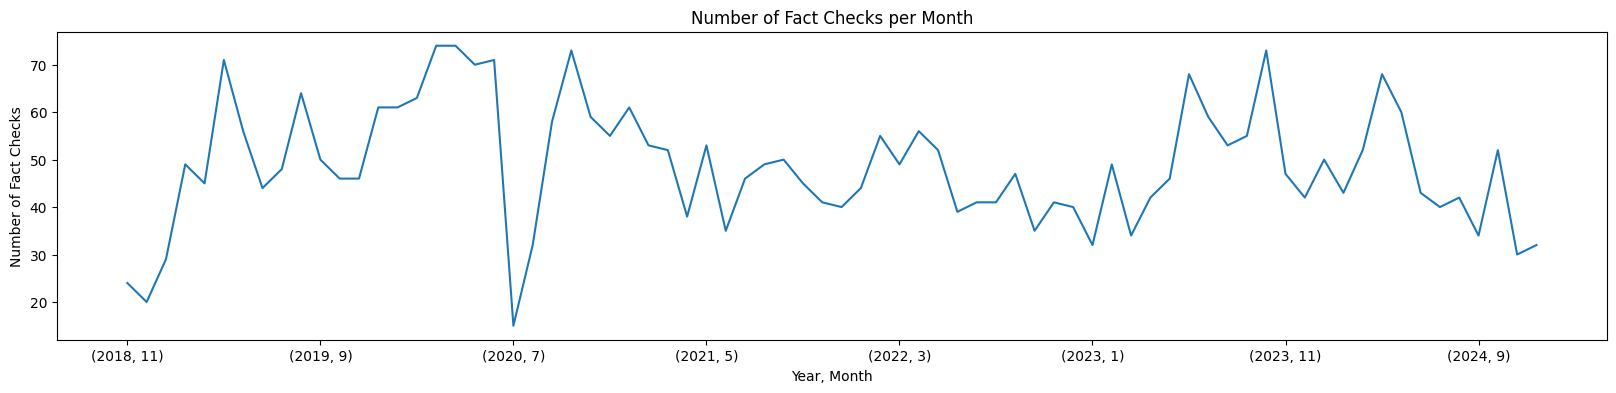

In [63]:
# plot the number of fact checks per month
plt.figure(figsize=(20, 4))
data5.groupby(['Year', 'Month']).size().plot()
plt.title('Number of Fact Checks per Month')
plt.xlabel('Year, Month')
plt.ylabel('Number of Fact Checks')
plt.show()